In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

MTRN = pd.read_csv('./trn_meta.csv', parse_dates=['datetime'])
MTST = pd.read_csv('./tst_meta.csv', parse_dates=['datetime'])

def count_loc(df):
    return df['loc'].value_counts().reindex(range(40), fill_value=0)

df_plot = pd.DataFrame({
    'TRN': count_loc(MTRN),
    'TST': count_loc(MTST)
})

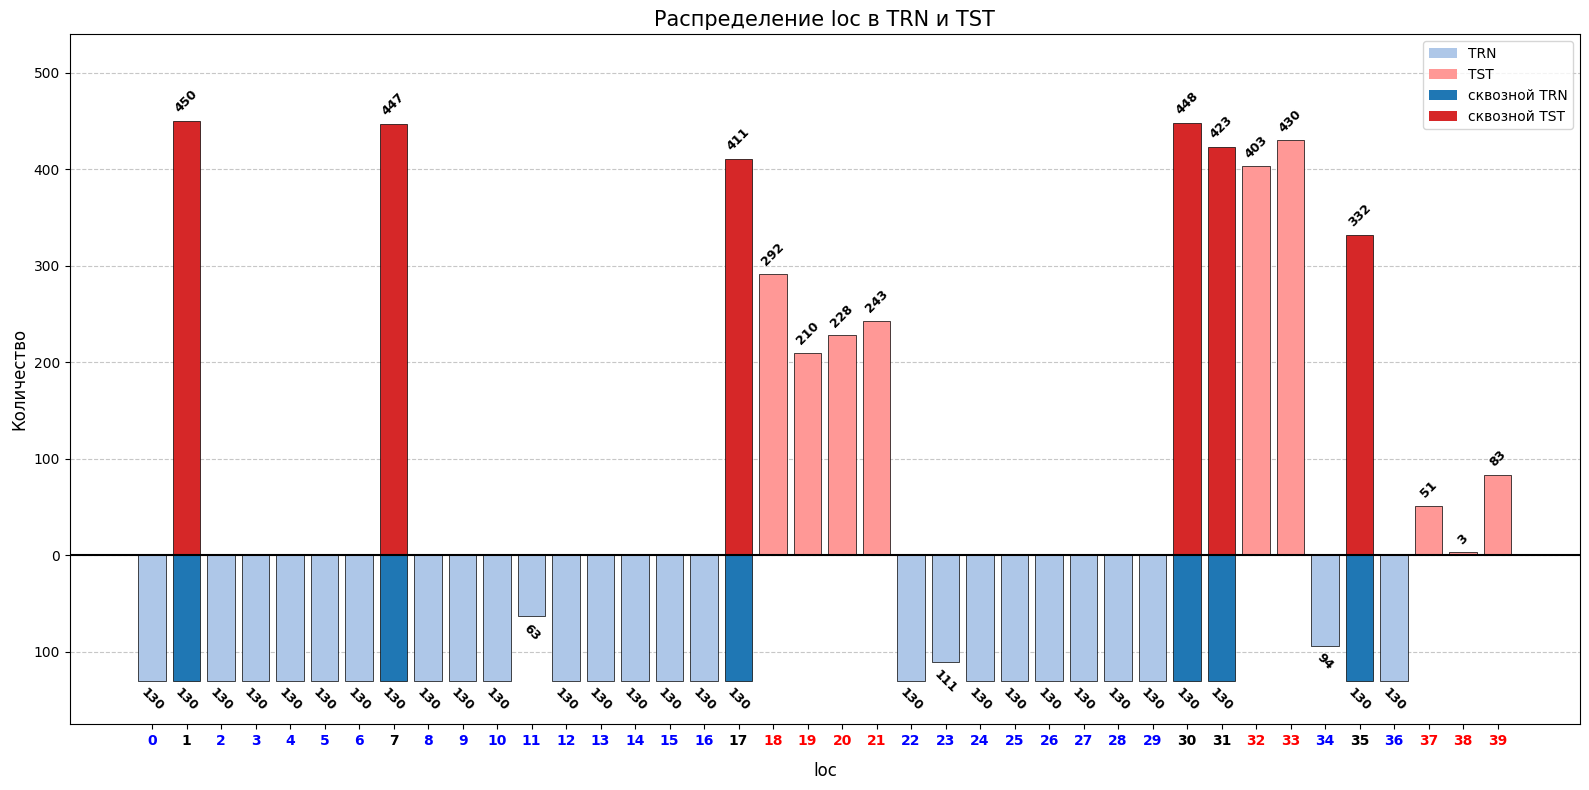

In [85]:
FADED = True

fig, ax = plt.subplots(figsize=(16, 8))

colors_tst =[]
colors_trn = []

for i in df_plot.index:
    val_trn = df_plot.loc[i, 'TRN']
    val_tst = df_plot.loc[i, 'TST']
    if val_tst > 0 and val_trn == 0:
        colors_tst.append('#ff9896' if FADED else '#d62728')
    else:
        colors_tst.append('#d62728')
    if val_trn > 0 and val_tst == 0:
        colors_trn.append('#aec7e8' if FADED else '#1f77b4')
    else:
        colors_trn.append('#1f77b4')

bars_tst = ax.bar(df_plot.index, df_plot['TST'], color=colors_tst, width=0.8, zorder=3, edgecolor='black', linewidth=0.5)
bars_trn = ax.bar(df_plot.index, -df_plot['TRN'], color=colors_trn, width=0.8, zorder=3, edgecolor='black', linewidth=0.5)

ax.axhline(0, color='black', linewidth=1.5, zorder=4)
ax.set_xticks(range(40))

for i, label in enumerate(ax.get_xticklabels()):
    val_trn = df_plot.loc[i, 'TRN']
    val_tst = df_plot.loc[i, 'TST']
    if val_trn > 0 and val_tst == 0:
        label.set_color('blue')
    elif val_tst > 0 and val_trn == 0:
        label.set_color('red')
    else:
        label.set_color('black')
    label.set_fontweight('bold')

labels_tst =[str(int(v)) if v > 0 else '' for v in df_plot['TST']]
ax.bar_label(bars_tst, labels=labels_tst, padding=4, rotation=45, fontweight='bold', fontsize=9)

labels_trn =[str(int(v)) if v > 0 else '' for v in df_plot['TRN']]
ax.bar_label(bars_trn, labels=labels_trn, padding=4, rotation=-45, fontweight='bold', fontsize=9)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: str(abs(int(x)))))

max_tst = df_plot['TST'].max()
max_trn = df_plot['TRN'].max()
ax.set_ylim(-max_trn * 1.35, max_tst * 1.20)

plt.title('Распределение loc в TRN и TST', fontsize=15)
plt.xlabel('loc', fontsize=12, labelpad=10)
plt.ylabel('Количество', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

legend_elements =([
    Patch(facecolor='#aec7e8', label='TRN'),
    Patch(facecolor='#ff9896', label='TST'),
    Patch(facecolor='#1f77b4', label='сквозной TRN'),
    Patch(facecolor='#d62728', label='сквозной TST'),
] if FADED else [
    Patch(facecolor='#1f77b4', label='TRN'),
    Patch(facecolor='#d62728', label='TST'),
])
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()